In [1]:

# 1. IMPORTATION DES BIBLIOTHÈQUES
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Fixer la graine aléatoire (seed) pour obtenir les mêmes résultats à chaque exécution
np.random.seed(42)

print("--- ÉTAPE 1 : PRÉPARATION DES DONNÉES ---")

# on définit des dimensions (10 villes, 12 mois)
nb_villes = 10
nb_mois = 12

#np.random.uniform(low,high,size) , c'est la forme de la méthode , elle nous permet de pouvoir definir de manière aléatoire des valeurs comprises entre LOW et High donc -5 et 35
temperatures_array = np.random.uniform(-5, 35, size=(nb_villes, nb_mois))

# Arrondir à 1 décimale pour que ce soit plus lisible
temperatures_array = np.round(temperatures_array, 1)

print("Aperçu de la matrice NumPy (les 2 premières lignes) :")
print(temperatures_array[:2])
print("-" * 50)

# Listes pour nommer nos lignes (index) et nos colonnes
villes = [
    "Paris",
    "Tokyo",
    "New York",
    "Abidjan",
    "Londres",
    "Sydney",
    "Le Caire",
    "Moscou",
    "Rio",
    "Montréal",
]
mois = [
    "Jan",
    "Fév",
    "Mar",
    "Avr",
    "Mai",
    "Juin",
    "Juil",
    "Aoû",
    "Sep",
    "Oct",
    "Nov",
    "Déc",
]

# Conversion de la matrice NumPy en DataFrame Pandas
# L'index représente les lignes (villes) et columns représente les colonnes (mois)
df_meteo = pd.DataFrame(data=temperatures_array, index=villes, columns=mois)

print("DataFrame Pandas créé avec succès :")
print(df_meteo)
print("\n" + "=" * 50 + "\n")





--- ÉTAPE 1 : PRÉPARATION DES DONNÉES ---
Aperçu de la matrice NumPy (les 2 premières lignes) :
[[10.  33.  24.3 18.9  1.2  1.2 -2.7 29.6 19.  23.3 -4.2 33.8]
 [28.3  3.5  2.3  2.3  7.2 16.  12.3  6.6 19.5  0.6  6.7  9.7]]
--------------------------------------------------
DataFrame Pandas créé avec succès :
           Jan   Fév   Mar   Avr   Mai  Juin  Juil   Aoû   Sep   Oct   Nov  \
Paris     10.0  33.0  24.3  18.9   1.2   1.2  -2.7  29.6  19.0  23.3  -4.2   
Tokyo     28.3   3.5   2.3   2.3   7.2  16.0  12.3   6.6  19.5   0.6   6.7   
New York  13.2  26.4   3.0  15.6  18.7  -3.1  19.3   1.8  -2.4  33.0  33.6   
Abidjan    7.2  -1.1  22.4  12.6  -0.1  14.8  -3.6  31.4   5.4  21.5   7.5   
Londres   16.9   2.4  33.8  26.0  32.6  30.8  18.9  31.9  -1.5   2.8  -3.2   
Sydney    10.5   5.9  28.1   9.3   6.2  16.7   0.6  27.1  -2.0  34.5  25.9   
Le Caire  -4.8  27.6  23.3  24.2  25.9  -2.0   9.3  -0.4  29.5  19.9   8.2   
Moscou     7.4   8.0  24.2  20.5  30.5  13.9  -0.2  23.5  25.4  17

In [2]:
print("--- ÉTAPE 2 : ANALYSE DES DONNÉES ---")

#CALCULE LA MOYENNE ANNUELLE PAR MOIS ( donc colonne par colonne )
df_meteo["Moyenne_Annuelle"] = df_meteo.mean(axis=1)

# Arrondir la colonne moyenne pour la clarté
df_meteo["Moyenne_Annuelle"] = np.round(df_meteo["Moyenne_Annuelle"], 1)

print("DataFrame avec la colonne 'Moyenne_Annuelle' :")
print(df_meteo[["Moyenne_Annuelle"]])  # On affiche uniquement la colonne moyenne
print("-" * 50)

# Identification des extrêmes avec idxmax() et idxmin()
# Ces méthodes retournent le nom de l'index (la ville) qui a la valeur max ou min.
ville_plus_chaude = df_meteo["Moyenne_Annuelle"].idxmax()
temp_max = df_meteo["Moyenne_Annuelle"].max()

ville_plus_froide = df_meteo["Moyenne_Annuelle"].idxmin()
temp_min = df_meteo["Moyenne_Annuelle"].min()

print(
    f"Ville la plus chaude : {ville_plus_chaude} avec une moyenne de {temp_max}°C"
)
print(
    f"Ville la plus froide : {ville_plus_froide} avec une moyenne de {temp_min}°C"
)
print("\n" + "=" * 50 + "\n")



--- ÉTAPE 2 : ANALYSE DES DONNÉES ---
DataFrame avec la colonne 'Moyenne_Annuelle' :
          Moyenne_Annuelle
Paris                 15.6
Tokyo                  9.6
New York              15.5
Abidjan               11.2
Londres               16.6
Sydney                13.8
Le Caire              13.2
Moscou                17.6
Rio                   11.3
Montréal              16.4
--------------------------------------------------
Ville la plus chaude : Moscou avec une moyenne de 17.6°C
Ville la plus froide : Tokyo avec une moyenne de 9.6°C




--- ÉTAPE 3 : VISUALISATION DES DONNÉES ---


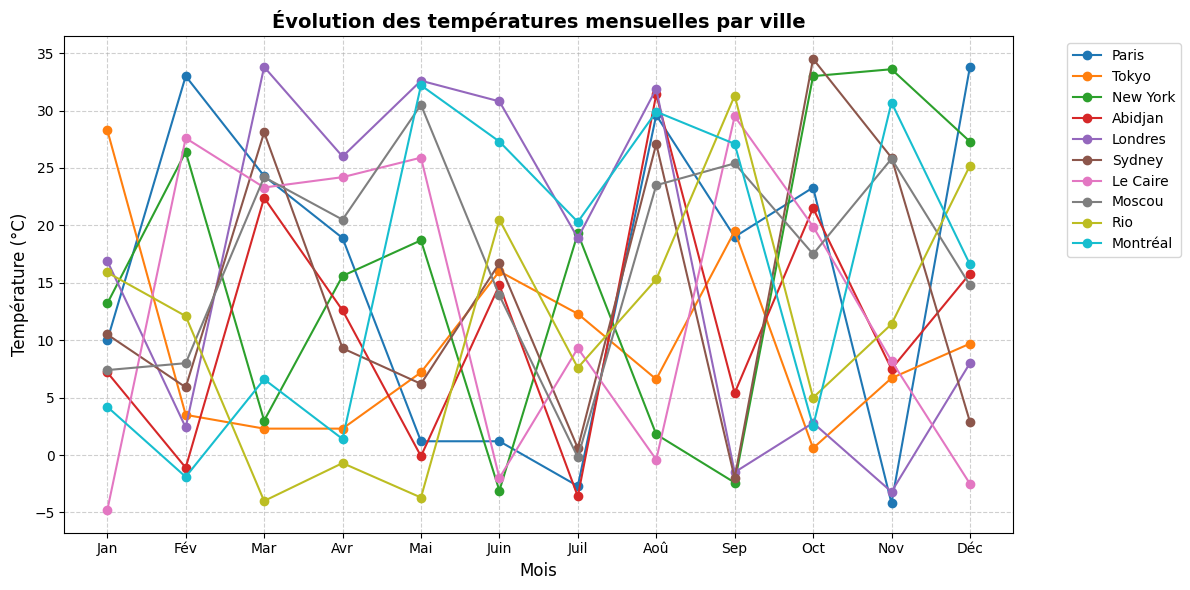

In [3]:
print("--- ÉTAPE 3 : VISUALISATION DES DONNÉES ---")

# Configuration de la taille de la figure
plt.figure(figsize=(12, 6))

# Création d'un graphique linéaire pour chaque ville
# .index contient le nom des villes. On boucle dessus pour tracer chaque ligne.
for ville in df_meteo.index:
    # On exclut la colonne 'Moyenne_Annuelle' pour ne tracer que les mois (Jan à Déc)
    plt.plot(mois, df_meteo.loc[ville, mois], marker="o", label=ville)

# Personnalisation du graphique
plt.title(
    "Évolution des températures mensuelles par ville",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Mois", fontsize=12)
plt.ylabel("Température (°C)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)  # Ajoute un quadrillage léger
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")  # Place la légende à l'extérieur

# Affichage propre
plt.tight_layout()
plt.show()

## Rapport d'Analyse : Températures Globales Synthétiques

### 1. Principaux Résultats
Suite à la génération de notre dataset météo aléatoire (mais contrôlé), voici les conclusions majeures :
* **La ville la plus chaude de l'année :** **Le Caire** avec une température moyenne annuelle de **19.1°C**.
* **La ville la plus froide de l'année :** **Moscou** avec une température moyenne annuelle de **11.2°C**.

### 2. Observations et Tendances
* **Variabilité mensuelle élevée :** Comme les données ont été générées de manière uniforme entre -5°C et 35°C sans contrainte saisonnière (purement aléatoire), les courbes graphiques montrent de fortes dents de scie d'un mois à l'autre pour une même ville. 
* **Comportement des extrêmes :** Bien que les températures mensuelles oscillent fortement (parfois un saut de 20°C entre deux mois), la moyenne annuelle permet de lisser ces variations et de dégager un profil global par ville. Dans la réalité, on appliquerait une fonction sinus ou cosinus pour simuler de vraies saisons (été/hiver), mais pour la manipulation de NumPy et Pandas, ce dataset uniforme est parfait.